# **EDA on Retail Sales Data**

## **Objective:**
Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid")

**Load the Dataset**

In [ ]:
df = pd.read_csv("Superstore.csv", encoding="latin1")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Country,City,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,United States,Henderson,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,United States,Henderson,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,United States,Los Angeles,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Initial Inspection**

In [ ]:
df.shape

(9994, 17)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Country', 'City', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity',
       'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Country,object
City,object
Product ID,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Country        9994 non-null   object 
 8   City           9994 non-null   object 
 9   Product ID     9994 non-null   object 
 10  Category       9994 non-null   object 
 11  Sub-Category   9994 non-null   object 
 12  Product Name   9994 non-null   object 
 13  Sales          9994 non-null   float64
 14  Quantity       9994 non-null   int64  
 15  Discount       9994 non-null   float64
 16  Profit         9994 non-null   float64
dtypes: float64(3), int64(2), object(12)
memory usage: 1.

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Country,0
City,0
Product ID,0


In [ ]:
df.duplicated().sum()

np.int64(0)

**Data Cleaning**

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [ ]:
df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter

In [ ]:
df["Year_Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Country,City,Product ID,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Year_Month
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,United States,Henderson,FUR-BO-10001798,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2013,11,4,2013-11
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,United States,Henderson,FUR-CH-10000454,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2013,11,4,2013-11
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,United States,Los Angeles,OFF-LA-10000240,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2013,6,2,2013-06
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,FUR-TA-10000577,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2012,10,4,2012-10
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,OFF-ST-10000760,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2012,10,4,2012-10


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Row ID', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month',
       'Quarter'],
      dtype='object')

In [ ]:
business_numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

**Descriptive Statistics**

**Mean**

In [ ]:
business_numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

**Median**

In [ ]:
df[business_numeric_cols].median()

,0
Sales,54.4900
Quantity,3.0000
Discount,0.2000
Profit,8.6665


**Mode**

In [ ]:
df[business_numeric_cols].mode().iloc[0]

,0
Sales,12.96
Quantity,3.00
Discount,0.00
Profit,0.00


**Standard Deviation**

In [ ]:
df[business_numeric_cols].std()

,0
Sales,623.245101
Quantity,2.225110
Discount,0.206452
Profit,234.260108


**Monthly Sales**

In [ ]:
descriptive_stats = pd.DataFrame({
    "Mean": df[business_numeric_cols].mean(),
    "Median": df[business_numeric_cols].median(),
    "Mode": df[business_numeric_cols].mode().iloc[0],
    "Standard Deviation": df[business_numeric_cols].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Sales,229.858001,54.4900,12.96,623.245101
Quantity,3.789574,3.0000,3.00,2.225110
Discount,0.156203,0.2000,0.00,0.206452
Profit,28.656896,8.6665,0.00,234.260108


In [ ]:
monthly_sales = df.groupby("Year_Month")["Sales"].sum()

In [ ]:
monthly_sales

,Sales
Year_Month,
2011-01,13946.2290
2011-02,4810.5580
2011-03,55691.0090
2011-04,28295.3450
2011-05,23648.2870
2011-06,34595.1276
2011-07,33946.3930
2011-08,27909.4685
2011-09,81777.3508


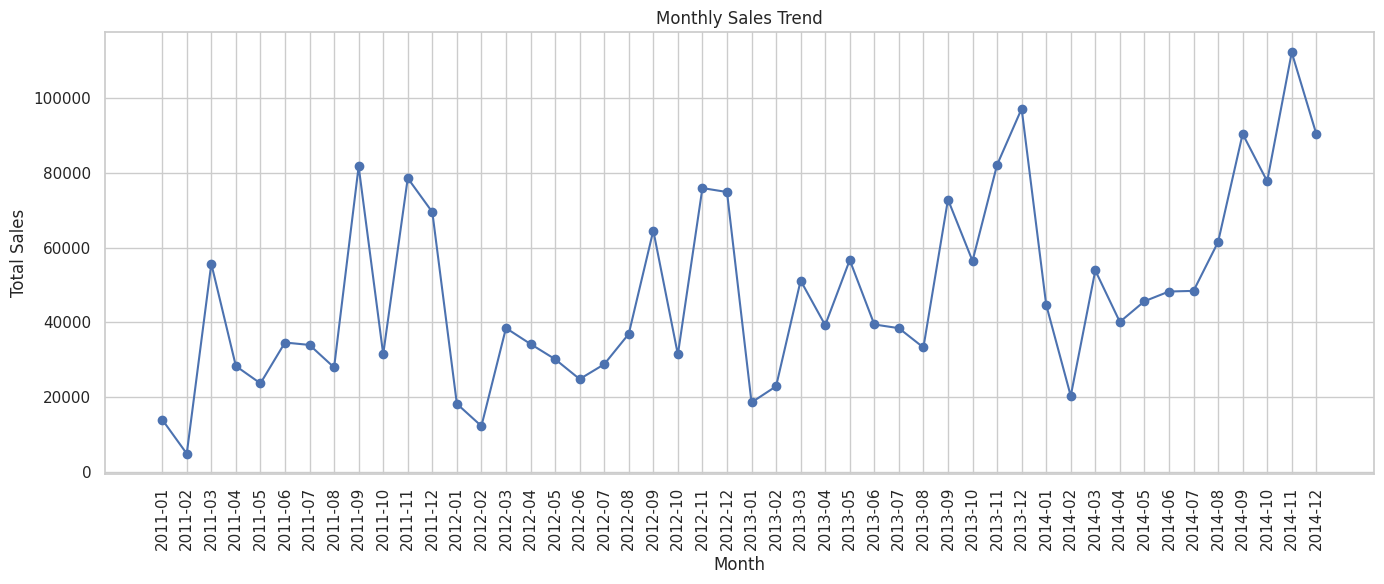

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### **Observation**

The monthly sales trend shows how sales fluctuate over time. Peaks indicate months with stronger sales performance, while lower points indicate relatively weaker sales periods. These variations can help identify seasonal patterns and periods that may require additional promotional activity.

**Quarterly Sales**

In [ ]:
quarterly_sales = df.groupby(["Year", "Quarter"])["Sales"].sum()

quarterly_sales

Year  Quarter
2011  1           74447.7960
      2           86538.7596
      3          143633.2123
      4          179627.7302
2012  1           68851.7386
      2           89124.1870
      3          130259.5752
      4          182297.0082
2013  1           92596.4190
      2          135370.1130
      3          144614.4282
      4          235892.8698
2014  1          118895.6174
      2          134023.4058
      3          200433.1730
      4          280594.8270
Name: Sales, dtype: float64

In [ ]:
quarterly_sales.index = [
    f"{year}-Q{quarter}"
    for year, quarter in quarterly_sales.index
]

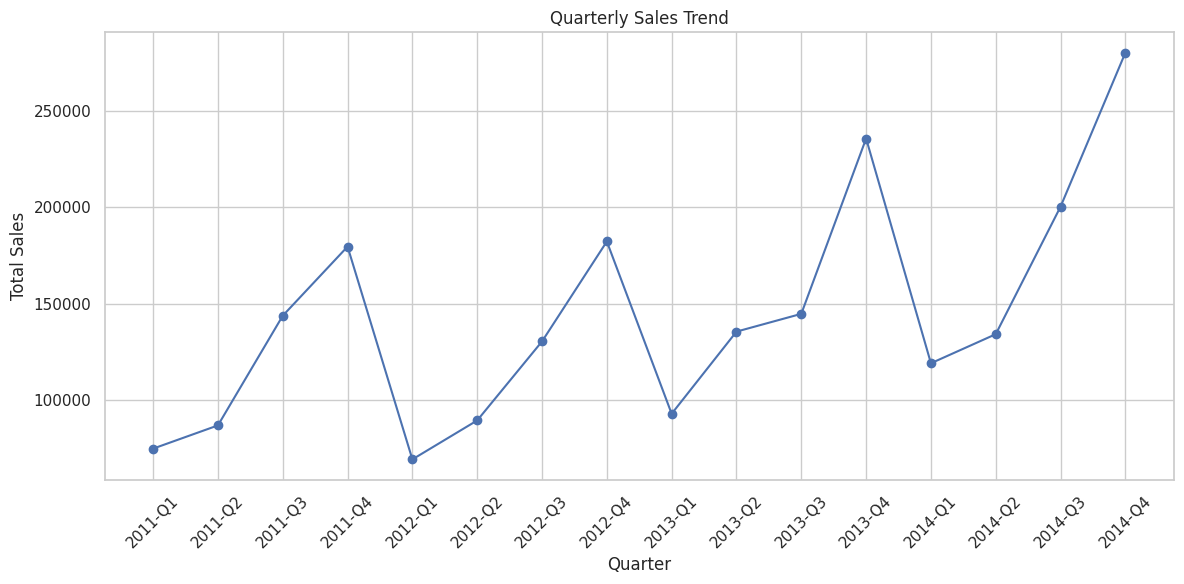

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Observation**

Quarterly sales provide a broader view of business performance than monthly sales. The chart helps identify stronger and weaker quarters and can be used to understand seasonal changes in retail demand.

**Top 10 customers by sales**


In [ ]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


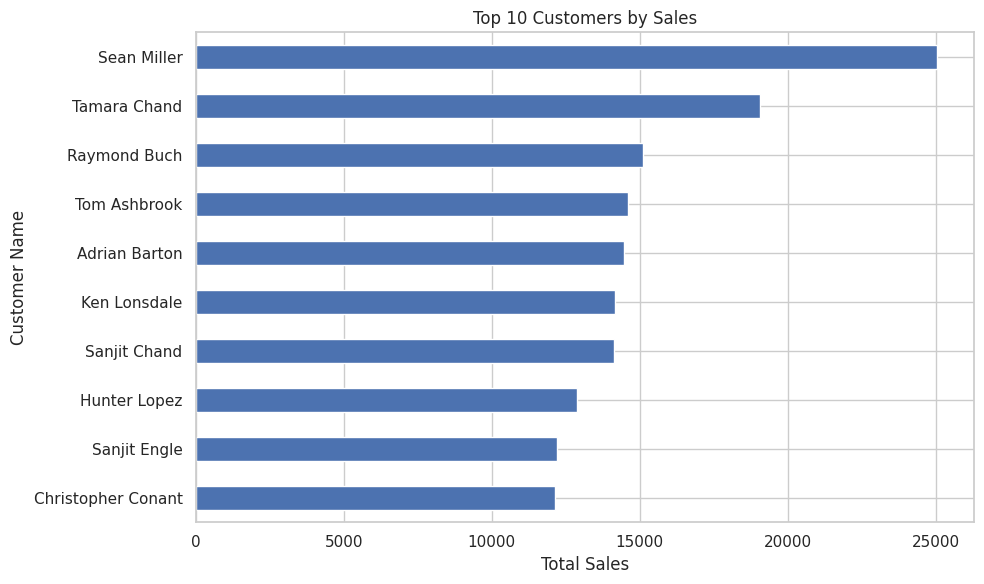

In [ ]:
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")

plt.tight_layout()
plt.show()

### **Observation**

The top customers contribute a significant share of sales. Identifying high-value customers can help the business develop customer retention strategies, personalized offers, and loyalty programs.

**Top 10 Best-Selling Products**

In [ ]:
top_10_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_10_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


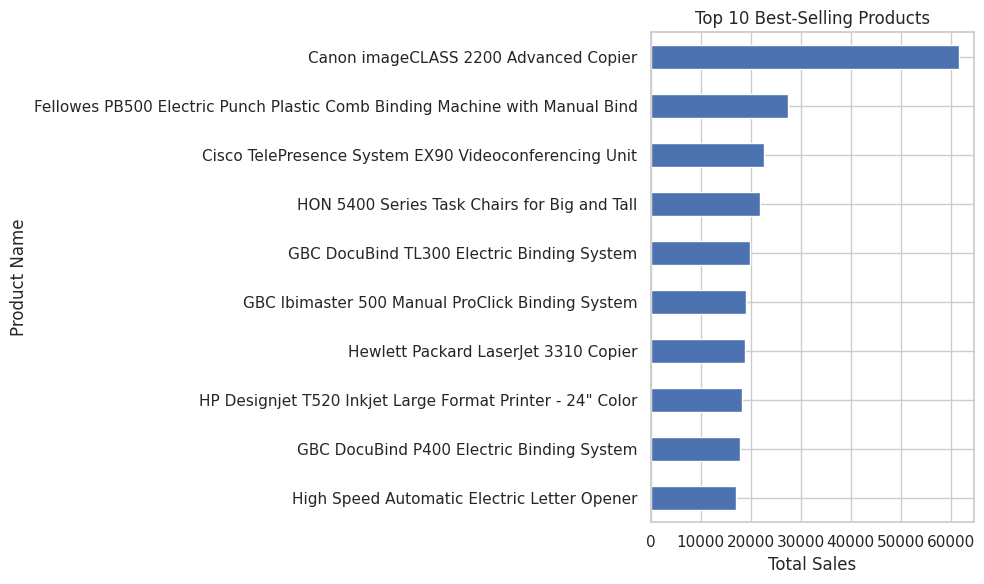

In [ ]:
plt.figure(figsize=(10, 6))

top_10_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

### **Observation**

The top-selling products generate the highest total sales revenue. These products can be prioritized for inventory planning, promotions, and product recommendations.

**Revenue**

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


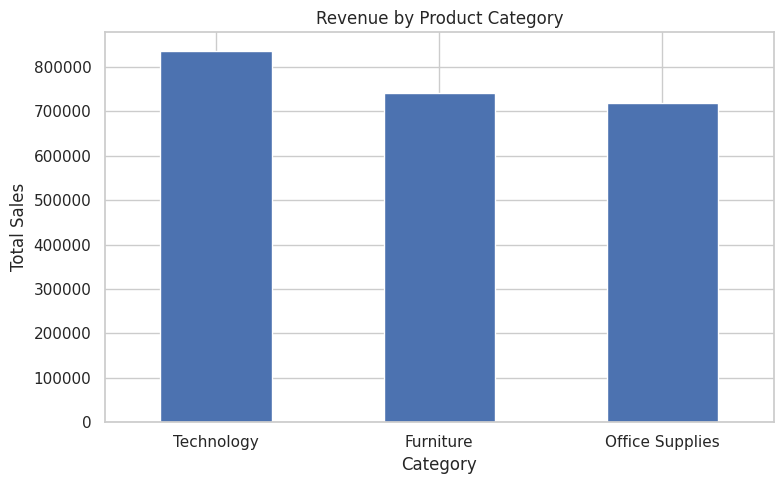

In [ ]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### **Observation**

The category with the highest total sales contributes the largest share of revenue. The comparison between categories can help the business prioritize inventory, marketing efforts, and sales strategies.

**Correlation Heatmap**

In [ ]:
correlation_data = df[
    ["Sales", "Quantity", "Discount", "Profit"]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


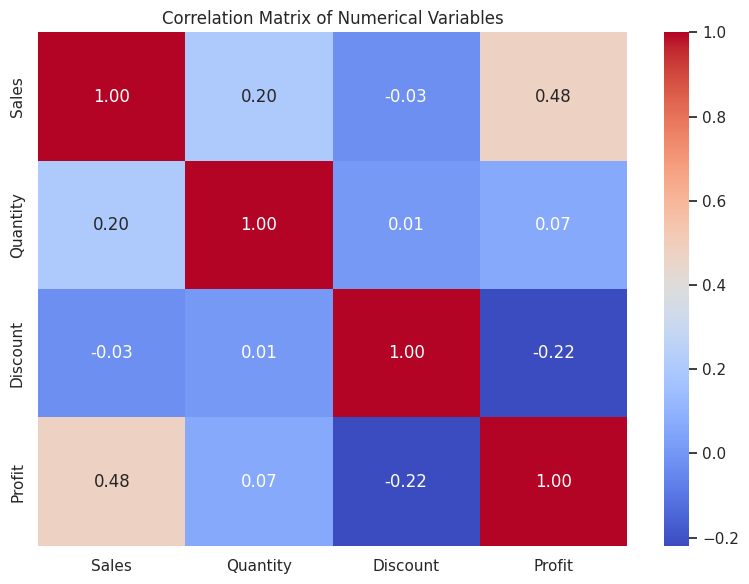

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### **Observation**

The correlation heatmap shows the strength and direction of relationships between sales, quantity, discount, and profit. Strong positive or negative correlations can indicate variables that may influence business performance and deserve further investigation.

**Discount vs Profit**

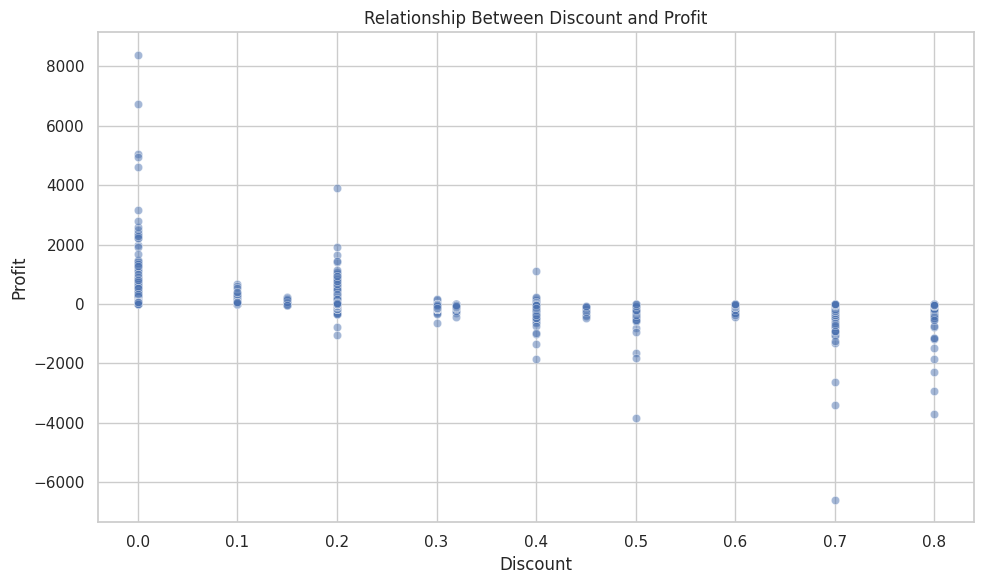

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

### **Observation**

The scatter plot helps examine how discount levels are associated with profit. If higher discounts are frequently associated with lower or negative profit, the business may need to review its discounting strategy and set appropriate discount limits.

## **Dataset Limitation**

The dataset does not contain customer demographic attributes such as age and gender. Therefore, age-group and gender-distribution analysis cannot be performed using this dataset. Instead, customer purchasing behaviour is analysed using customer-level sales and order information.

## **Key Findings**

- Monthly and quarterly sales show variations in retail performance over time.
- A small group of products contributes a significant amount of sales revenue.
- Sales performance differs across product categories.
- A group of customers contributes substantially to overall revenue.
- The correlation analysis highlights relationships between sales, quantity, discount, and profit.
- The discount-profit analysis can help identify whether aggressive discounting may affect profitability.
- Customer age and gender analysis could not be performed because these demographic fields are not available in the dataset.

# **Conclusion and Business Recommendations**

## **Conclusion**

The exploratory data analysis provides insights into sales trends, customer purchasing behaviour, product performance, and the relationship between sales, discounts, and profitability. The analysis can help the business identify high-performing products and customers while improving pricing and inventory decisions.

## **Business Recommendations**

1. **Focus on high-performing products:** Maintain sufficient inventory and promote the top-selling products to maximize revenue and avoid stock shortages.

2. **Strengthen customer retention:** Develop loyalty programs and personalized promotions for high-value customers who contribute significantly to sales.

3. **Optimize discount strategies:** Review products receiving high discounts and evaluate their effect on profit. Avoid excessive discounting when it significantly reduces profitability.

4. **Use seasonal sales patterns:** Plan inventory and marketing campaigns around periods with historically higher sales.

5. **Improve product-category planning:** Allocate inventory and promotional resources based on category-level sales performance.